## (0) Loading Bibs and Data 

In [26]:
import pandas as pd
import matplotlib.pyplot as plt 
from ydata_profiling import ProfileReport
from collections import Counter
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

%matplotlib inline

In [6]:
df_1 = pd.read_csv('../../data/05_goemotions_1_pt.csv')
df_2 = pd.read_csv('../../data/05_goemotions_2_pt.csv')
df_3 = pd.read_csv('../../data/05_goemotions_3_pt.csv')

df = pd.concat([df_1, df_2, df_3])
df.drop(columns=['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id'], inplace=True)

print(df.shape)
df.head(3)

(211225, 30)


,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,texto
0,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,Aquele jogo doeu.
1,True,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,>sexualidade não deve ser uma categoria de agr...
2,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,"Você faz certo, se você não se importa, então ..."


## (1) Data Overview an Descriptive Statistics

In [7]:
df.dtypes # data types

example_very_unclear      bool
admiration               int64
amusement                int64
anger                    int64
annoyance                int64
approval                 int64
caring                   int64
confusion                int64
curiosity                int64
desire                   int64
disappointment           int64
disapproval              int64
disgust                  int64
embarrassment            int64
excitement               int64
fear                     int64
gratitude                int64
grief                    int64
joy                      int64
love                     int64
nervousness              int64
optimism                 int64
pride                    int64
realization              int64
relief                   int64
remorse                  int64
sadness                  int64
surprise                 int64
neutral                  int64
texto                   object
dtype: object

In [8]:
df[df.duplicated()] # check duplicated rows

,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,texto
244,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,"[NAME] para [NAME]: ""Não tente me dizer como d..."
328,False,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"""Sponge Blurb Pubs Quaw Haha GURR ha AAa!"" fin..."
882,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,Esta é uma ladeira escorregadia que termina co...
1167,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,Lembre-me! 3 meses
1578,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,Este é o debate mais agradável que já tive no ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71215,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,Youtube é minha Wikipédia. Vídeos sobre qualqu...
71218,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"Obrigado, [NOME]"
71220,False,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Todo mundo gosta de [NOME].
71222,False,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Isso parece incrível


In [9]:
df.isna().sum() # missing values per feature

example_very_unclear    0
admiration              0
amusement               0
anger                   0
annoyance               0
approval                0
caring                  0
confusion               0
curiosity               0
desire                  0
disappointment          0
disapproval             0
disgust                 0
embarrassment           0
excitement              0
fear                    0
gratitude               0
grief                   0
joy                     0
love                    0
nervousness             0
optimism                0
pride                   0
realization             0
relief                  0
remorse                 0
sadness                 0
surprise                0
neutral                 0
texto                   0
dtype: int64

In [10]:
df.describe()

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
count,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,...,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000,211225.000000
mean,0.081103,0.043768,0.038272,0.064472,0.083418,0.028401,0.034840,0.045885,0.018071,0.040095,...,0.038779,0.008569,0.041259,0.006164,0.041591,0.006102,0.011954,0.031994,0.026105,0.261797
std,0.272994,0.204580,0.191853,0.245592,0.276514,0.166116,0.183374,0.209236,0.133208,0.196182,...,0.193067,0.092172,0.198890,0.078269,0.199653,0.077880,0.108679,0.175985,0.159448,0.439614
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
df.example_very_unclear.value_counts()

example_very_unclear
False    207814
True       3411
Name: count, dtype: int64

In [16]:
# Generate the report
profile = ProfileReport(df,title="GoEmotions Profile")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:13<00:00,  2.16it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## (2) Statistical and structural analyses of the text

In [17]:
# Distribuição do tamanho dos textos
df['n_chars'] = df['texto'].str.len()
df['n_words'] = df['texto'].str.split().str.len()

print(df['n_chars'].describe())
print(80*"-")
print(df['n_words'].describe())

count    211225.000000
mean         74.565440
std          39.791418
min           2.000000
25%          42.000000
50%          71.000000
75%         104.000000
max         703.000000
Name: n_chars, dtype: float64
--------------------------------------------------------------------------------
count    211225.000000
mean         13.150200
std           6.878392
min           1.000000
25%           7.000000
50%          13.000000
75%          18.000000
max          39.000000
Name: n_words, dtype: float64


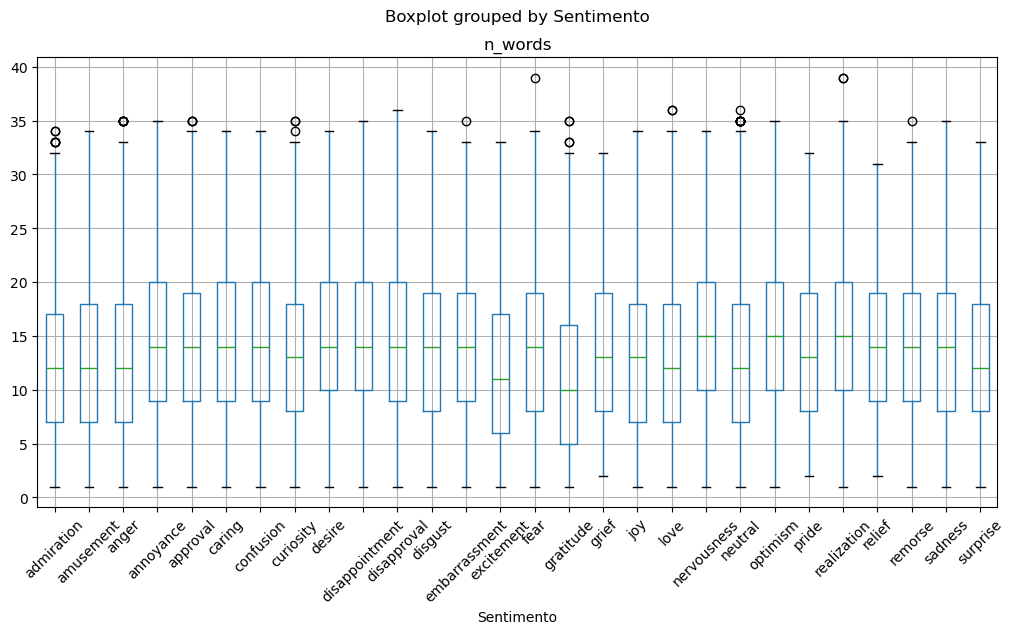

In [18]:
# Histogramas por sentimento
id_vars = ['n_words']
colunas_sentimento = df.drop(columns=['example_very_unclear', 'texto']).columns
df_melted = pd.melt(
    df,
    id_vars=id_vars,
    value_vars=colunas_sentimento,
    var_name='Sentimento',
    value_name='Presente'
)

df_bloxpot = df_melted[df_melted['Presente'] == 1].copy()

df_bloxpot.boxplot(column='n_words', by='Sentimento', figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

In [20]:
# Número de textos vazios ou quase vazios
print((df['texto'].str.strip().str.len() == 0).sum())
print((df['texto'].str.strip().str.len() == 3).sum())

0
28


## (3) Balance and distribution analyses of the target

In [21]:
colunas_sentimento = df.drop(columns=['example_very_unclear', 'texto']).columns

contagem_sentimento = df[colunas_sentimento].sum()

contagem_sentimento

admiration           17131
amusement             9245
anger                 8084
annoyance            13618
approval             17620
caring                5999
confusion             7359
curiosity             9692
desire                3817
disappointment        8469
disapproval          11424
disgust               5301
embarrassment         2476
excitement            5629
fear                  3197
gratitude            11625
grief                  673
joy                   7983
love                  8191
nervousness           1810
optimism              8715
pride                 1302
realization           8785
relief                1289
remorse               2525
sadness               6758
surprise              5514
neutral              55298
n_chars           15750085
n_words            2777651
dtype: int64

## (4) Word frequencies (without preprocessing)

In [22]:
Counter(" ".join(df['texto']).split()).most_common(30)

[('que', 91793),
 ('de', 81083),
 ('é', 52540),
 ('o', 50026),
 ('não', 45533),
 ('e', 41503),
 ('a', 41331),
 ('um', 39598),
 ('para', 32104),
 ('Eu', 29539),
 ('você', 28643),
 ('uma', 25975),
 ('eu', 25867),
 ('em', 24573),
 ('com', 23453),
 ('se', 20724),
 ('do', 19468),
 ('por', 18797),
 ('isso', 18097),
 ('[NAME]', 14908),
 ('mas', 14756),
 ('está', 14471),
 ('os', 14077),
 ('no', 13663),
 ('mais', 13579),
 ('como', 13194),
 ('me', 12587),
 ('ele', 12477),
 ('muito', 12035),
 ('[NOME]', 11348)]

In [23]:
# por sentimento
Counter(" ".join(df[df.caring==1]['texto']).split()).most_common(20)

[('que', 2788),
 ('de', 2242),
 ('você', 1867),
 ('e', 1702),
 ('o', 1449),
 ('a', 1377),
 ('não', 1345),
 ('para', 1316),
 ('um', 1201),
 ('se', 1197),
 ('é', 1125),
 ('com', 966),
 ('em', 773),
 ('por', 696),
 ('Você', 690),
 ('uma', 680),
 ('Eu', 664),
 ('está', 642),
 ('eu', 521),
 ('sua', 495)]

## (5) Detection of Emojis, Hashtags, and Mentions

In [24]:
df['has_emoji'] = df['texto'].str.contains(r'[\U00010000-\U0010ffff]')
df['has_hashtag'] = df['texto'].str.contains(r'#')
df['has_mention'] = df['texto'].str.contains(r'@')

df[['has_emoji','has_hashtag','has_mention']].mean()

has_emoji      0.017460
has_hashtag    0.002575
has_mention    0.000526
dtype: float64

## (6) Language checks

In [29]:
def detectar_idioma_seg(texto):
    texto_str = str(texto).strip()
    if not texto_str:
        return 'vazio'
    try:
        return detect(texto_str)
    except LangDetectException:
        return 'erro_detect' 

df['lang'] = df['texto'].apply(detectar_idioma_seg)
df.lang.value_counts().head()

KeyboardInterrupt: 

## (9) Correlation between text length and sentiment

In [31]:
# df_melted.groupby('Sentimento')['n_words'].mean()

## (10) Ponctuation Frequency

In [32]:
# df['n_exclamacoes'] = df['texto'].str.count('!')
# df['n_interrog'] = df['texto'].str.count('\?')

# df.groupby('sentimento')[['n_exclamacoes','n_interrog']].mean()